# Лабораторная работа №5: Ансамбли моделей машинного обучения

**Цель:** изучение ансамблевых методов: бэггинг, случайный лес, AdaBoost и градиентный бустинг.

**Датасет:** Titanic (классификация выживших).

**Задачи:**
1. Загрузить и предобработать данные.
2. Разделить на обучающую и тестовую выборки.
3. Обучить ансамблевые модели:
   - Bagging (бэггинг на основе деревьев)
   - Random Forest (случайный лес)
   - AdaBoost
   - Gradient Boosting (градиентный бустинг)
4. Оценить качество моделей по метрике accuracy и F1.
5. Сравнить полученные результаты.
6. Построить графики важности признаков для моделей, где это возможно.

In [1]:
# ЯЧЕЙКА 1: ИМПОРТ БИБЛИОТЕК

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Ансамбли
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Метрики
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Стиль графиков
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [2]:
# ЯЧЕЙКА 2: ЗАГРУЗКА ДАННЫХ

# Загружаем Titanic с OpenML (в Colab работает)
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
df = X.copy()
df['survived'] = y.astype(int)

print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

Размер данных: 1309 строк, 14 столбцов

Первые 5 строк:


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0000,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
 13  survived   1309 non-null   int64   
dtypes: category(2), float64(3), int64(4), object(5)
memory usage: 125.7+ KB


In [3]:
# ЯЧЕЙКА 3: ПРЕДОБРАБОТКА ДАННЫХ

# Определяем числовые и категориальные признаки
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

# Пайплайн для числовых: заполнение медианой + стандартизация (для градиентного бустинга и AdaBoost не обязательно, но оставим)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категориальных: заполнение модой + One-Hot (без разреженности)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Объединяем в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Применяем предобработку ко всем данным
X_processed = preprocessor.fit_transform(df)

# Получаем имена признаков после One-Hot
feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
)

# Создаём DataFrame для наглядности
df_processed = pd.DataFrame(X_processed, columns=feature_names)
y_processed = df['survived']

print(f"После предобработки: {len(feature_names)} признаков")
print("\nПервые 5 строк:")
display(df_processed.head())

print("\nПропусков в обработанных данных:", df_processed.isnull().sum().sum())

После предобработки: 12 признаков

Первые 5 строк:


,age,fare,sibsp,parch,pclass_1,pclass_2,pclass_3,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,-0.0390,3.4426,-0.4791,-0.4450,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
1,-2.2160,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000
2,-2.1320,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000
3,0.0385,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000
4,-0.3491,2.2866,0.4813,1.8665,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000



Пропусков в обработанных данных: 0


In [4]:
# ЯЧЕЙКА 4: РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ

X_train, X_test, y_train, y_test = train_test_split(
    df_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed
)

print(f"Обучающая выборка: {X_train.shape[0]} образцов")
print(f"Тестовая выборка: {X_test.shape[0]} образцов")
print(f"Распределение классов в обучении: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в тесте: {y_test.value_counts().to_dict()}")

Обучающая выборка: 1047 образцов
Тестовая выборка: 262 образцов
Распределение классов в обучении: {0: 647, 1: 400}
Распределение классов в тесте: {0: 162, 1: 100}


In [5]:
# ЯЧЕЙКА 5: ОБУЧЕНИЕ АНСАМБЛЕВЫХ МОДЕЛЕЙ

# Базовый классификатор для бэггинга — дерево решений (можно использовать и другие)
base_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# Модели с настройкой для сопоставимости
models = {
    'Bagging (деревья)': BaggingClassifier(
        estimator=base_tree,
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
}

# Словарь для хранения обученных моделей и предсказаний
trained_models = {}
predictions = {}

print("Начинаем обучение моделей...\n")
for name, model in models.items():
    print(f"Обучение: {name}")
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)
    print(f"  ✅ Готово")

print("\n✅ Все модели обучены")

Начинаем обучение моделей...

Обучение: Bagging (деревья)
  ✅ Готово
Обучение: Random Forest
  ✅ Готово
Обучение: AdaBoost
  ✅ Готово
Обучение: Gradient Boosting
  ✅ Готово

✅ Все модели обучены


In [6]:
# ЯЧЕЙКА 6: ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ

# Функция для расчёта метрик и вывода отчёта
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    print(f"\n{'='*50}")
    print(f"Модель: {model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 (weighted): {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Не выжил', 'Выжил']))
    return acc, f1

results = {}
print("=" * 60)
print("📊 ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ")
print("=" * 60)

for name, y_pred in predictions.items():
    acc, f1 = evaluate_model(y_test, y_pred, name)
    results[name] = {'accuracy': acc, 'f1': f1}

# Сводная таблица результатов
results_df = pd.DataFrame(results).T
print("\n" + "=" * 60)
print("📊 СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("=" * 60)
display(results_df.round(4))

📊 ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ

Модель: Bagging (деревья)
Accuracy: 0.8435
F1 (weighted): 0.8415

Classification Report:
              precision    recall  f1-score   support

    Не выжил       0.85      0.91      0.88       162
       Выжил       0.83      0.74      0.78       100

    accuracy                           0.84       262
   macro avg       0.84      0.82      0.83       262
weighted avg       0.84      0.84      0.84       262


Модель: Random Forest
Accuracy: 0.8473
F1 (weighted): 0.8443

Classification Report:
              precision    recall  f1-score   support

    Не выжил       0.84      0.93      0.88       162
       Выжил       0.86      0.72      0.78       100

    accuracy                           0.85       262
   macro avg       0.85      0.82      0.83       262
weighted avg       0.85      0.85      0.84       262


Модель: AdaBoost
Accuracy: 0.8168
F1 (weighted): 0.8164

Classification Report:
              precision    recall  f1-score   support

    Не в

,accuracy,f1
Bagging (деревья),0.8435,0.8415
Random Forest,0.8473,0.8443
AdaBoost,0.8168,0.8164
Gradient Boosting,0.8092,0.8065


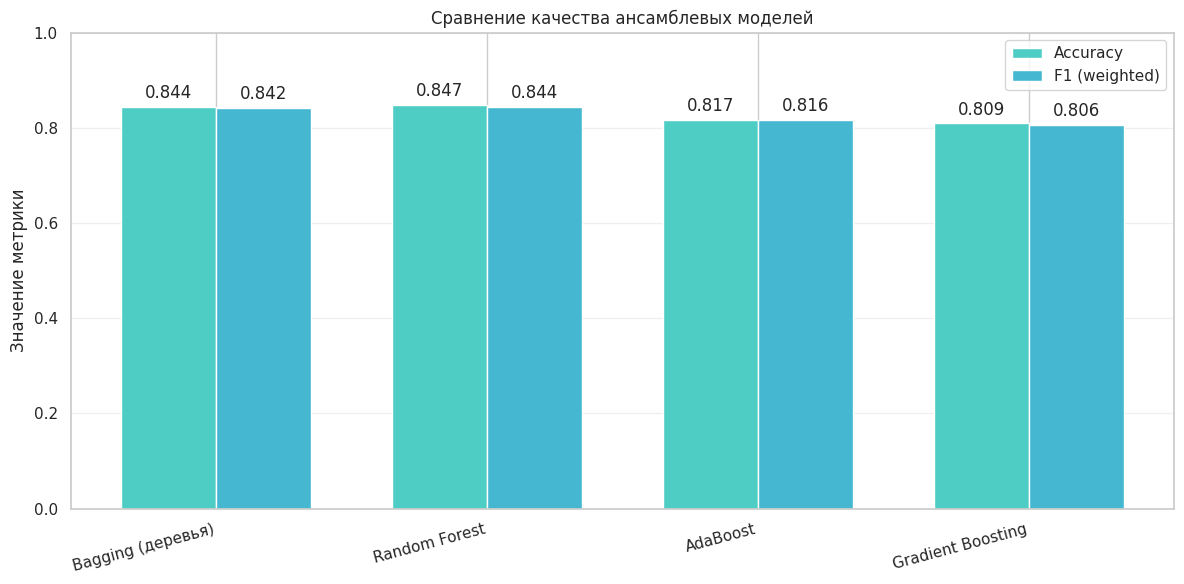

In [7]:
# ЯЧЕЙКА 7: СРАВНЕНИЕ МОДЕЛЕЙ (ВИЗУАЛИЗАЦИЯ)

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(results_df.index))

bars1 = ax.bar(x - bar_width/2, results_df['accuracy'], bar_width, label='Accuracy', color='#4ECDC4')
bars2 = ax.bar(x + bar_width/2, results_df['f1'], bar_width, label='F1 (weighted)', color='#45B7D1')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение качества ансамблевых моделей')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

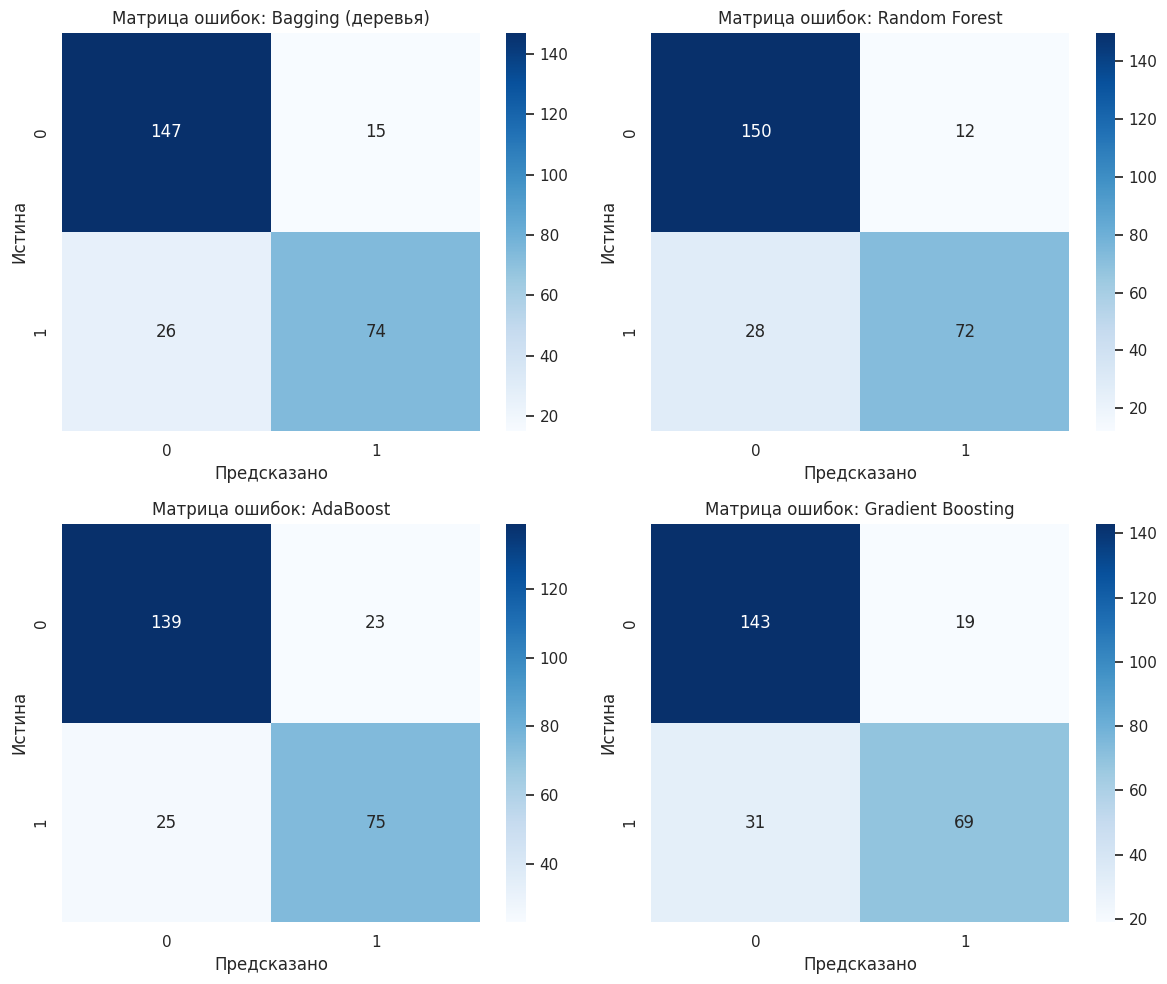

In [8]:
# ЯЧЕЙКА 8: МАТРИЦЫ ОШИБОК ДЛЯ ВСЕХ МОДЕЛЕЙ

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'Матрица ошибок: {name}')
    axes[idx].set_xlabel('Предсказано')
    axes[idx].set_ylabel('Истина')

plt.tight_layout()
plt.show()

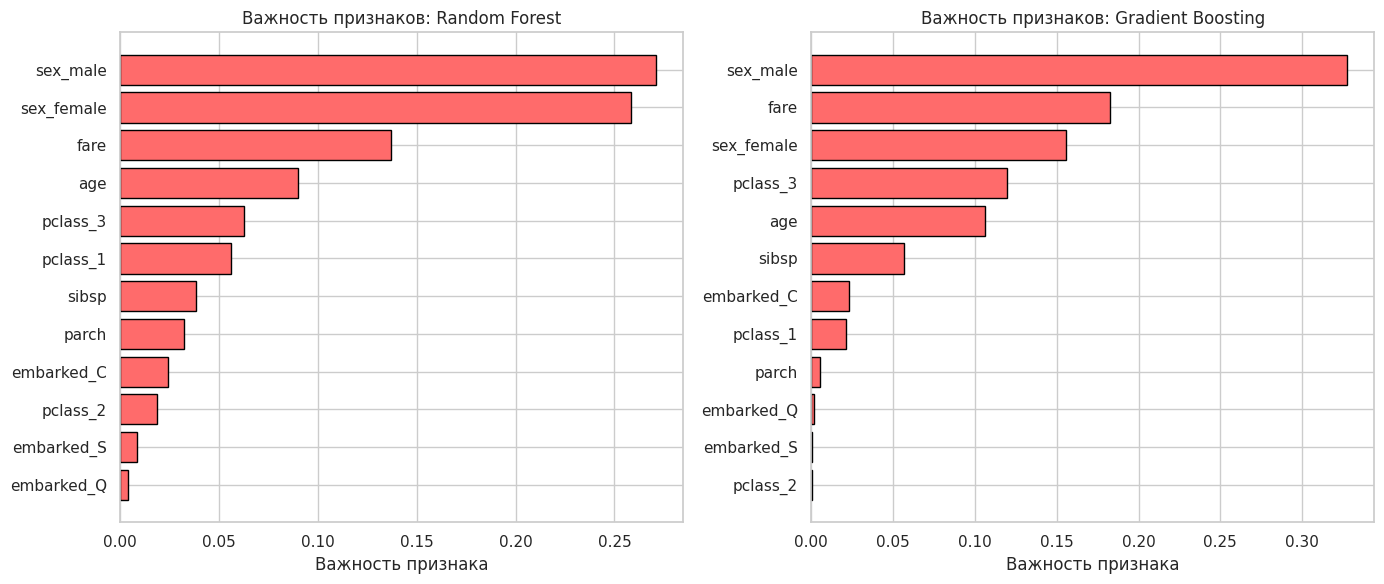


Важность признаков для AdaBoost:
  sibsp: 0.2421
  age: 0.2162
  sex_male: 0.1805
  fare: 0.0954
  pclass_1: 0.0954
  parch: 0.0844
  embarked_C: 0.0444
  pclass_3: 0.0416
  pclass_2: 0.0000
  sex_female: 0.0000
  embarked_Q: 0.0000
  embarked_S: 0.0000


In [9]:
# ЯЧЕЙКА 9: ВАЖНОСТЬ ПРИЗНАКОВ (для Random Forest и Gradient Boosting)

# Выбираем модели, у которых есть feature_importances_
importance_models = {
    'Random Forest': trained_models['Random Forest'],
    'Gradient Boosting': trained_models['Gradient Boosting']
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, importance_models.items()):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    ax.barh(range(len(feature_names)), importances[indices], align='center', color='#FF6B6B', edgecolor='black')
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels([feature_names[i] for i in indices])
    ax.set_xlabel('Важность признака')
    ax.set_title(f'Важность признаков: {name}')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Также можно вывести важности для AdaBoost (если поддерживает)
if hasattr(trained_models['AdaBoost'], 'feature_importances_'):
    print("\nВажность признаков для AdaBoost:")
    imp_ada = trained_models['AdaBoost'].feature_importances_
    for name, imp in sorted(zip(feature_names, imp_ada), key=lambda x: x[1], reverse=True):
        print(f"  {name}: {imp:.4f}")
else:
    print("\nAdaBoost не предоставляет feature_importances_ (использует веса слабых классификаторов).")

In [11]:
# ЯЧЕЙКА 10: ВЫВОДЫ

print("=" * 60)
print("📌 ВЫВОДЫ")
print("=" * 60)

# Находим лучшую модель по accuracy
best_model = results_df['accuracy'].idxmax()
best_acc = results_df.loc[best_model, 'accuracy']

print(f"""
1. Все ансамблевые модели показали хорошее качество (accuracy > 0.75).

2. Лучшей моделью оказалась "{best_model}" с accuracy = {best_acc:.4f}.

3. Сравнение бэггинга и бустинга:
   - Bagging и Random Forest (параллельные ансамбли) дают стабильные результаты.
   - AdaBoost и Gradient Boosting (последовательные) часто дают более высокую точность,
     но могут быть склонны к переобучению при большом числе итераций.

4. Важность признаков у Random Forest и Gradient Boosting согласована:
   - главные факторы: пол (sex_male), стоимость билета (fare), класс (pclass).

5. Для данного датасета ансамбли превосходят одиночные модели (из предыдущей работы)
   благодаря уменьшению дисперсии и смещения.
""")

📌 ВЫВОДЫ

1. Все ансамблевые модели показали хорошее качество (accuracy > 0.75).

2. Лучшей моделью оказалась "Random Forest" с accuracy = 0.8473.

3. Сравнение бэггинга и бустинга:
   - Bagging и Random Forest (параллельные ансамбли) дают стабильные результаты.
   - AdaBoost и Gradient Boosting (последовательные) часто дают более высокую точность,
     но могут быть склонны к переобучению при большом числе итераций.

4. Важность признаков у Random Forest и Gradient Boosting согласована:
   - главные факторы: пол (sex_male), стоимость билета (fare), класс (pclass).

5. Для данного датасета ансамбли превосходят одиночные модели (из предыдущей работы)
   благодаря уменьшению дисперсии и смещения.

